# Customer Churn Analysis

This notebook explores telecom customer churn data and builds models to predict customer attrition.

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("deep")


In [113]:
df = pd.read_csv("../data/telco_churn.csv")

## Dataset Overview

Before performing deeper analysis, we first examine the structure of the dataset, including the number of features, data types, and potential missing values.

In [114]:
df.shape

(7043, 21)

In [115]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observation

The `TotalCharges` column appears as an `object` data type, even though it should represent numeric values.

### Investigation

Further inspection suggests that some entries in this column contain blank spaces, which prevents pandas from interpreting the column as numeric.

### Implication

This issue will need to be addressed during data preprocessing so that the column can be converted into a proper numeric format for analysis and modeling.

In [117]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [118]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [119]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Churn Distribution

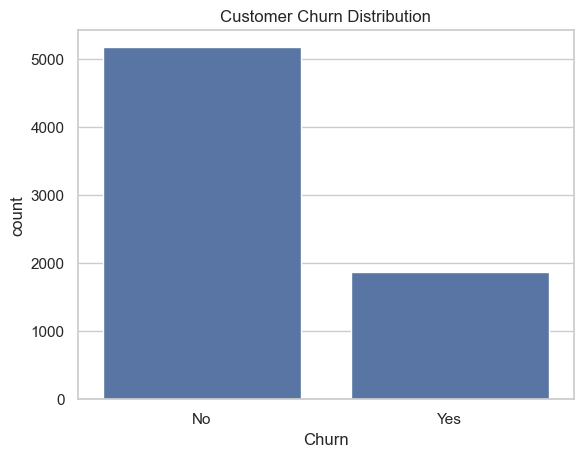

In [120]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()



The dataset contains 7043 customers.

Out of these:
- 5174 customers did **not churn**
- 1869 customers **churned**

This corresponds to approximately:
- **73% non-churned customers**
- **27% churned customers**

This indicates that the dataset is **imbalanced**, with significantly more non-churned customers than churned ones.

This imbalance is important because machine learning models trained on such data may become biased toward the majority class. Therefore, evaluation metrics such as **precision, recall, and F1-score** will be more informative than accuracy alone.

## Churn by Contract Type

Do customers with different contract types churn at different rates?

Understanding this relationship can help identify whether certain contract structures are associated with higher customer attrition.

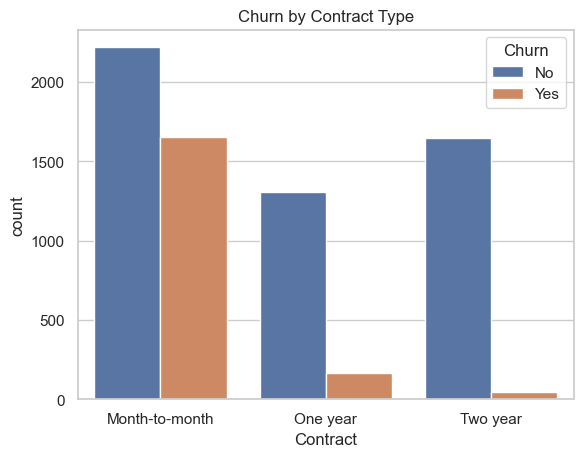

In [121]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

### Insight

Customers with month-to-month contracts appear to churn significantly more often than customers with one-year or two-year contracts.

This suggests that customers without long-term commitment are at a higher risk of leaving, while longer contracts may improve retention.

## Churn by Customer Tenure

We examine whether customers with shorter tenure are more likely to churn.

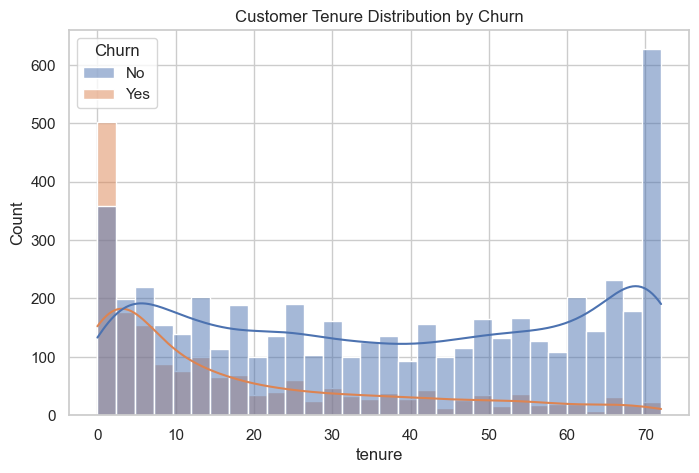

In [122]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Customer Tenure Distribution by Churn")
plt.show()

### Insight

Customers with shorter tenure appear to churn more frequently than customers who have been with the company for a longer period.

This suggests that the early stage of the customer lifecycle is a critical period for retention. New customers may still be evaluating the service and are therefore more likely to leave compared to long-term customers who have already established a stable relationship with the provider.

## Churn by Monthly Charges

We analyze whether customers with higher monthly charges are more likely to churn.

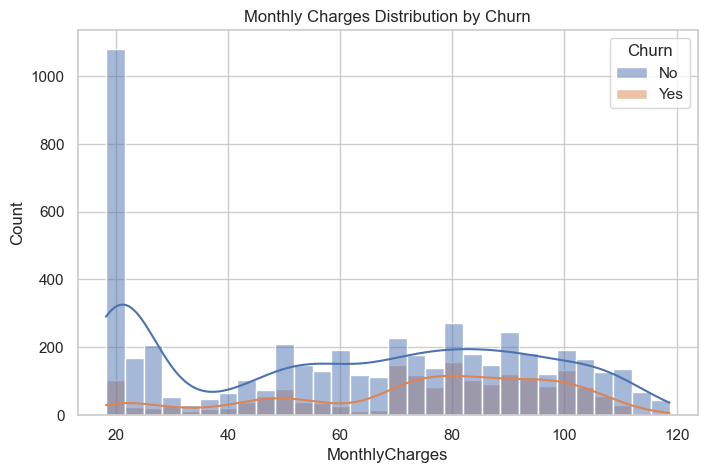

In [123]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

### Insight
Customers with higher monthly charges appear to churn more frequently.  This suggests that pricing may play a role in customer retention.

## Churn by Internet Service Type

We examine whether different internet service types are associated with different churn behavior.

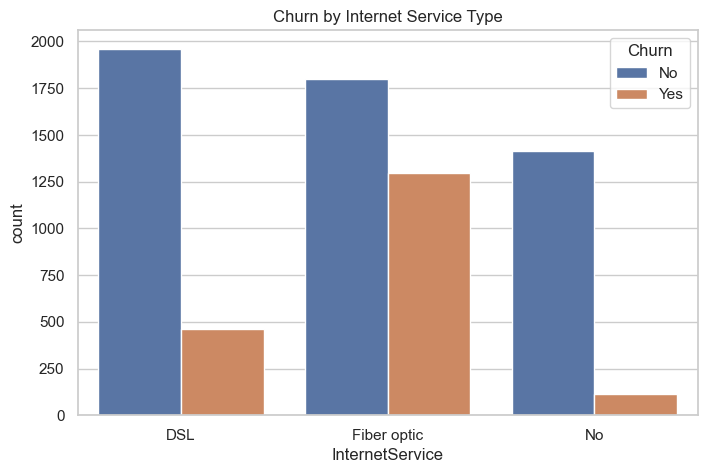

In [124]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service Type")
plt.show()

In [125]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Insight

Customers using fiber optic internet appear to churn more frequently compared to customers using DSL or those without internet service.

This may indicate that fiber optic customers experience higher dissatisfaction, possibly due to higher costs or service expectations. Further analysis would be required to determine the underlying causes.

Customers using fiber optic internet have a significantly higher churn rate compared to DSL customers.

## Churn by Payment Method

We analyze whether the payment method used by customers is associated with churn behavior.

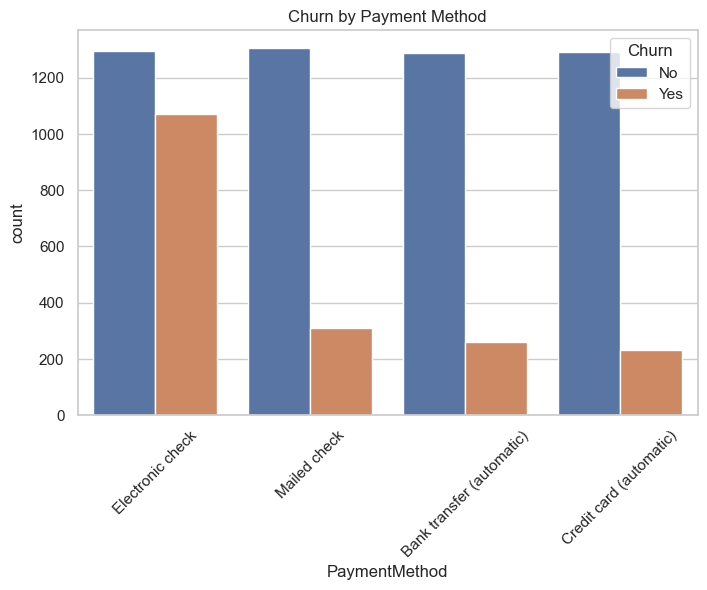

In [126]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

### Insight

Customers using **electronic check** as their payment method appear to churn significantly more frequently than customers using automatic payment methods such as bank transfer or credit card.

This may indicate that customers who do not use automatic billing are less engaged with the service or may experience more friction during the payment process.

Encouraging customers to adopt automatic payment methods could potentially improve customer retention.

Data pre processing

In [127]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [128]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [129]:
df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [130]:
sns.get_dataset_names

<function seaborn.utils.get_dataset_names()>

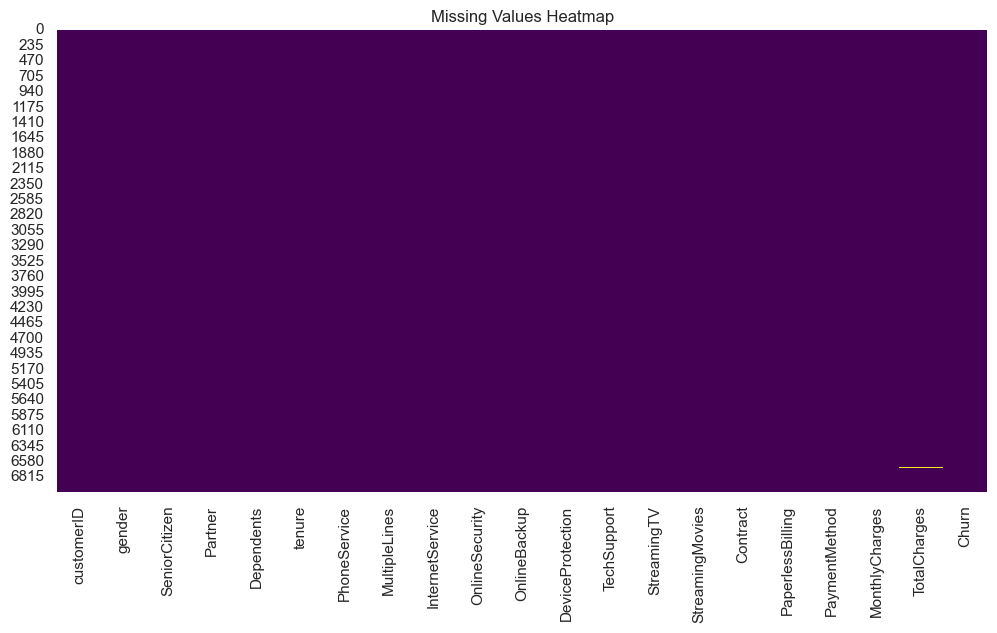

In [131]:
plt.figure(figsize=(12,6))
sns.heatmap(data=df.isnull(), cbar=False,cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


In [132]:
df = df.dropna()

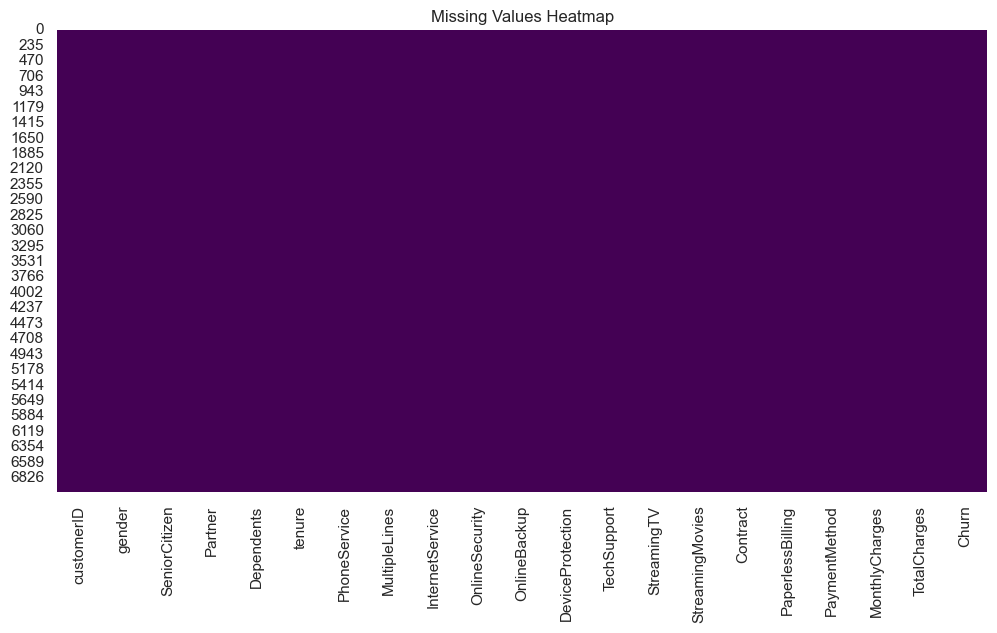

In [133]:
plt.figure(figsize=(12,6))
sns.heatmap(data=df.isnull(), cbar=False,cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


In [135]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [136]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [137]:
df = df.drop('customerID',axis=1)

In [138]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [139]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


array([0, 1])

### Target Variable Encoding

The target variable `Churn` originally contained categorical values ("Yes" and "No").  
For machine learning models, the target variable must be numeric, so it was converted to binary values:

- **1 → Customer churned**
- **0 → Customer did not churn**


In [142]:
df = pd.get_dummies(data=df,drop_first= True)

In [143]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [144]:
df.isnull().sum().sum()

np.int64(0)

## Data Preprocessing

Before training machine learning models, several preprocessing steps were performed to clean and prepare the dataset.

### 1. Data Type Correction
The `TotalCharges` column was originally stored as an object type due to the presence of blank values. It was converted to a numeric data type using `pd.to_numeric()` with invalid values coerced to `NaN`.

### 2. Handling Missing Values
A small number of missing values (11 rows) were identified in the `TotalCharges` column. Since this represented a very small portion of the dataset, these rows were removed.

### 3. Removing Non-Predictive Features
The `customerID` column was dropped because it serves only as a unique identifier and does not provide predictive information for churn.

### 4. Target Variable Encoding
The target variable `Churn` originally contained categorical values (`Yes` and `No`). These were converted to binary values:

- `1` → Customer churned  
- `0` → Customer retained

### 5. Encoding Categorical Features
Several features contained categorical values (e.g., contract type, payment method, internet service). These were transformed into numeric variables using **one-hot encoding** via `pd.get_dummies()`.

The parameter `drop_first=True` was used to avoid multicollinearity by removing one reference category from each encoded feature.

After preprocessing, the dataset contains only numeric values and is ready for machine learning models.